**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _COMPARE TWO MACHINE LEARNING MODELS USING A/B TESTING CONCEPTS_. 🧠🧪📊**

This script demonstrates how to simulate an **A/B test** for ML models by comparing:

- **Model A** → current production model
- **Model B** → new candidate model

A/B testing helps decide whether a new model should replace an existing one based on measurable performance.

---

## **📦 Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

---

## **🧩 Load Dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

---

## **✂️ Split Data**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

---

## **🤖 Train Model A**

Model A represents the current production model.

In [4]:
model_a = LogisticRegression(
    max_iter=5000
)

model_a.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


---

## **🚀 Train Model B**

Model B represents the new candidate model.

In [5]:
model_b = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_b.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

## **📊 Generate Predictions**

In [6]:
pred_a = model_a.predict(X_test)
pred_b = model_b.predict(X_test)

---

## **📈 Compare Model Metrics**

In [7]:
results = pd.DataFrame({
    "model": ["Model A", "Model B"],

    "accuracy": [
        accuracy_score(y_test, pred_a),
        accuracy_score(y_test, pred_b)
    ],

    "precision": [
        precision_score(y_test, pred_a),
        precision_score(y_test, pred_b)
    ],

    "recall": [
        recall_score(y_test, pred_a),
        recall_score(y_test, pred_b)
    ],

    "f1_score": [
        f1_score(y_test, pred_a),
        f1_score(y_test, pred_b)
    ]
})

print(results)

     model  accuracy  precision    recall  f1_score
0  Model A  0.947368   0.937500  0.981308  0.958904
1  Model B  0.941520   0.944954  0.962617  0.953704


---

## **📊 Visualize A/B Test Results**

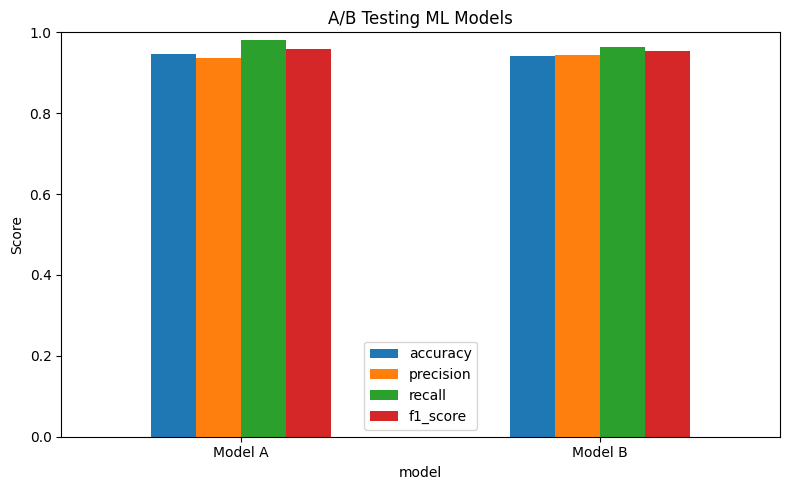

In [8]:
results.set_index("model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("A/B Testing ML Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

## **✅ Choose Winning Model**

In [9]:
winner = results.loc[
    results["f1_score"].idxmax(),
    "model"
]

print("Winning Model:", winner)

Winning Model: Model A


---

## **🔍 Why A/B Testing Matters**

A/B testing helps ML teams:

- compare production vs candidate models
- reduce deployment risk
- validate model improvement
- make data-driven release decisions
- avoid blindly replacing models

---

## **🧠 Key Takeaways**

1. A/B testing compares two model versions fairly.
2. Model A usually represents the current production model.
3. Model B represents a new candidate model.
4. Multiple metrics should be compared, not accuracy alone.
5. A/B testing supports safer ML model deployment.

---

## **Conclusion**

A/B testing is a key practice in production machine learning. Instead of deploying a new model blindly, we compare it against the current model using measurable results. This helps teams make safer, data-driven decisions when improving ML systems.

---